# PASTIS-R 数据可视化

浏览 `/mnt/ht2_nas2/00-model/00-fb/mmseg_data/PASTIS-R/DATA_S2` 中的 Sentinel-2 遥感影像及其标注。

数据说明：
- `S2_<ID>.npy`：形状 `[T=43, C=10, H=128, W=128]`，int16，43 个时间步 × 10 个波段 × 128×128 像素
- `TARGET_<ID>.npy`：形状 `[3, H, W]`，uint8，通道 0 为语义标签
- 波段顺序：B02(蓝), B03(绿), B04(红), B05, B06, B07, B08, B08A, B11, B12
- RGB = B04(idx 2), B03(idx 1), B02(idx 0)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

DATA_ROOT = Path("/mnt/ht2_nas2/00-model/00-fb/mmseg_data/PASTIS-R")
S2_DIR = DATA_ROOT / "DATA_S2"
ANN_DIR = DATA_ROOT / "ANNOTATIONS"
META_PATH = DATA_ROOT / "metadata.geojson"

_RGB_IDX = [2, 1, 0]

RGB_MEAN = np.array([1436.7, 1387.7, 1180.2])
RGB_STD  = np.array([1996.2, 1916.8, 1976.7])

In [18]:
patch_id = 10000
s2 = np.load(S2_DIR / f"S2_{patch_id}.npy").astype(np.float32)
# img = np.median(s2, axis=0)
img = s2.mean(axis=0)
rgb = img[_RGB_IDX].transpose(1, 2, 0)
ann = np.load(ANN_DIR / f"TARGET_{patch_id}.npy")
labels = ann[1]

In [2]:
with open(META_PATH) as f:
    meta = json.load(f)

n_patches = len(meta["features"])
print(f"Total patches: {n_patches}")

folds = {}
for feat in meta["features"]:
    f = feat["properties"]["Fold"]
    folds[f] = folds.get(f, 0) + 1
print(f"Fold distribution: {dict(sorted(folds.items()))}")
print(f"\nTrain (Fold 1-3): {folds[1] + folds[2] + folds[3]} patches")
print(f"Val   (Fold 4):   {folds[4]} patches")
print(f"Test  (Fold 5):   {folds[5]} patches")

first = meta["features"][0]
print(f"\nExample patch ID: {first['properties']['ID_PATCH']}, "
      f"Fold: {first['properties']['Fold']}, "
      f"Parcels: {first['properties']['N_Parcel']}")
print(f"Tile: {first['properties']['TILE']}")
print(f"S2 timesteps: {len(first['properties']['dates-S2'])}")

Total patches: 2433
Fold distribution: {1: 487, 2: 494, 3: 474, 4: 482, 5: 496}

Train (Fold 1-3): 1455 patches
Val   (Fold 4):   482 patches
Test  (Fold 5):   496 patches

Example patch ID: 10000, Fold: 1, Parcels: 119
Tile: t30uxv
S2 timesteps: 43


## Load & Display a Single Patch

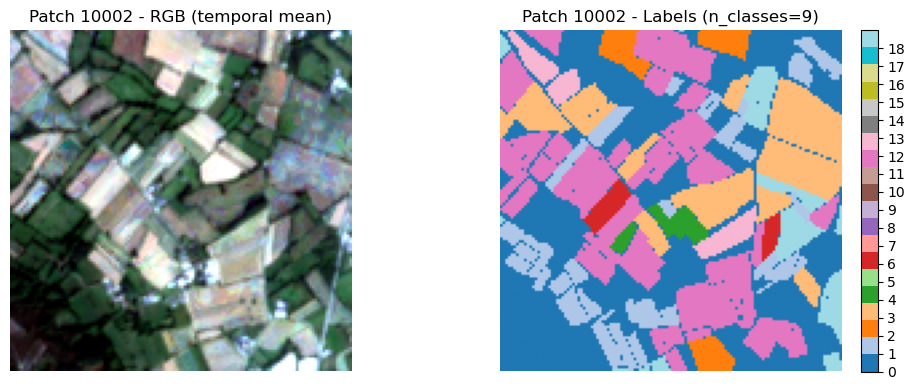

In [21]:
def load_patch(patch_id):
    s2 = np.load(S2_DIR / f"S2_{patch_id}.npy").astype(np.float32)
    img = np.median(s2, axis=0)
    # img = s2.mean(axis=0)
    rgb = img[_RGB_IDX].transpose(1, 2, 0)
    ann = np.load(ANN_DIR / f"TARGET_{patch_id}.npy")
    labels = ann[0].astype(np.int64)
    return rgb, labels


def show_patch(patch_id, ax=None, normalize=True):
    rgb, labels = load_patch(patch_id)
    if ax is None:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    else:
        ax1, ax2 = ax
    rgb_display = rgb.copy()
    if normalize:
        for c in range(3):
            lo, hi = np.percentile(rgb_display[..., c], [2, 98])
            rgb_display[..., c] = np.clip((rgb_display[..., c] - lo) / max(hi - lo, 1), 0, 1)
    ax1.imshow(rgb_display)
    ax1.set_title(f"Patch {patch_id} - RGB (temporal mean)")
    ax1.axis("off")
    im = ax2.imshow(labels, cmap="tab20", vmin=0, vmax=19)
    ax2.set_title(f"Patch {patch_id} - Labels (n_classes={len(np.unique(labels))})")
    ax2.axis("off")
    ax2.figure.colorbar(im, ax=ax2, fraction=0.046, pad=0.04,ticks=range(19))
    if ax is None:
        plt.tight_layout()
        plt.show()


show_patch(10002)

## Browse Samples from Different Folds

In [16]:
samples_by_fold = {1: [], 2: [], 3: [], 4: [], 5: []}
for feat in meta["features"]:
    f = feat["properties"]["Fold"]
    pid = int(feat["properties"]["ID_PATCH"])
    samples_by_fold[f].append(pid)

for fold, ids in samples_by_fold.items():
    print(f"Fold {fold}: {len(ids)} patches, e.g. {ids[:3]}")

Fold 1: 487 patches, e.g. [10000, 10007, 10030]
Fold 2: 494 patches, e.g. [10001, 10015, 10021]
Fold 3: 474 patches, e.g. [10005, 10006, 10009]
Fold 4: 482 patches, e.g. [10002, 10004, 10008]
Fold 5: 496 patches, e.g. [10003, 10010, 10012]


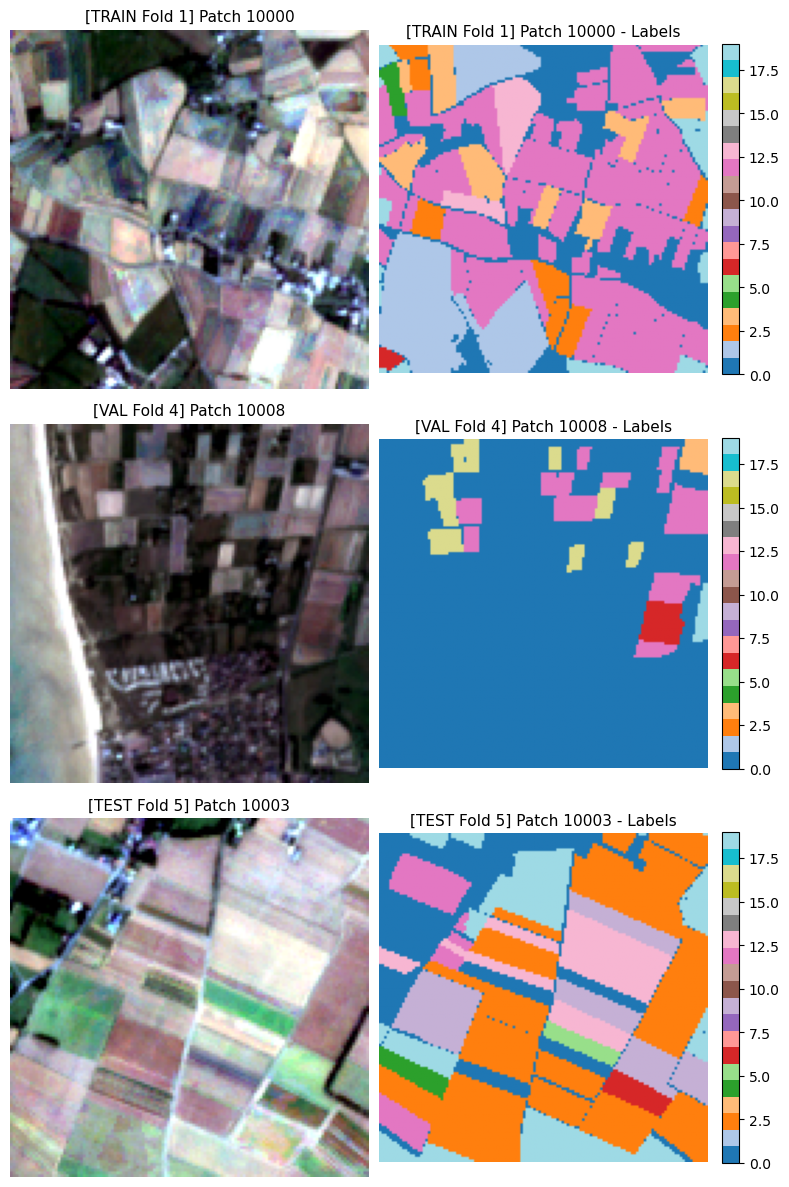

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(8,12))

train_id = samples_by_fold[1][0]
val_id   = samples_by_fold[4][2]
test_id  = samples_by_fold[5][0]

show_patch(train_id, ax=axes[0])
axes[0][0].set_title(f"[TRAIN Fold 1] Patch {train_id}", fontsize=11)
axes[0][1].set_title(f"[TRAIN Fold 1] Patch {train_id} - Labels", fontsize=11)

show_patch(val_id, ax=axes[1])
axes[1][0].set_title(f"[VAL Fold 4] Patch {val_id}", fontsize=11)
axes[1][1].set_title(f"[VAL Fold 4] Patch {val_id} - Labels", fontsize=11)

show_patch(test_id, ax=axes[2])
axes[2][0].set_title(f"[TEST Fold 5] Patch {test_id}", fontsize=11)
axes[2][1].set_title(f"[TEST Fold 5] Patch {test_id} - Labels", fontsize=11)

plt.tight_layout()
plt.show()

## Multi-Timestep Comparison

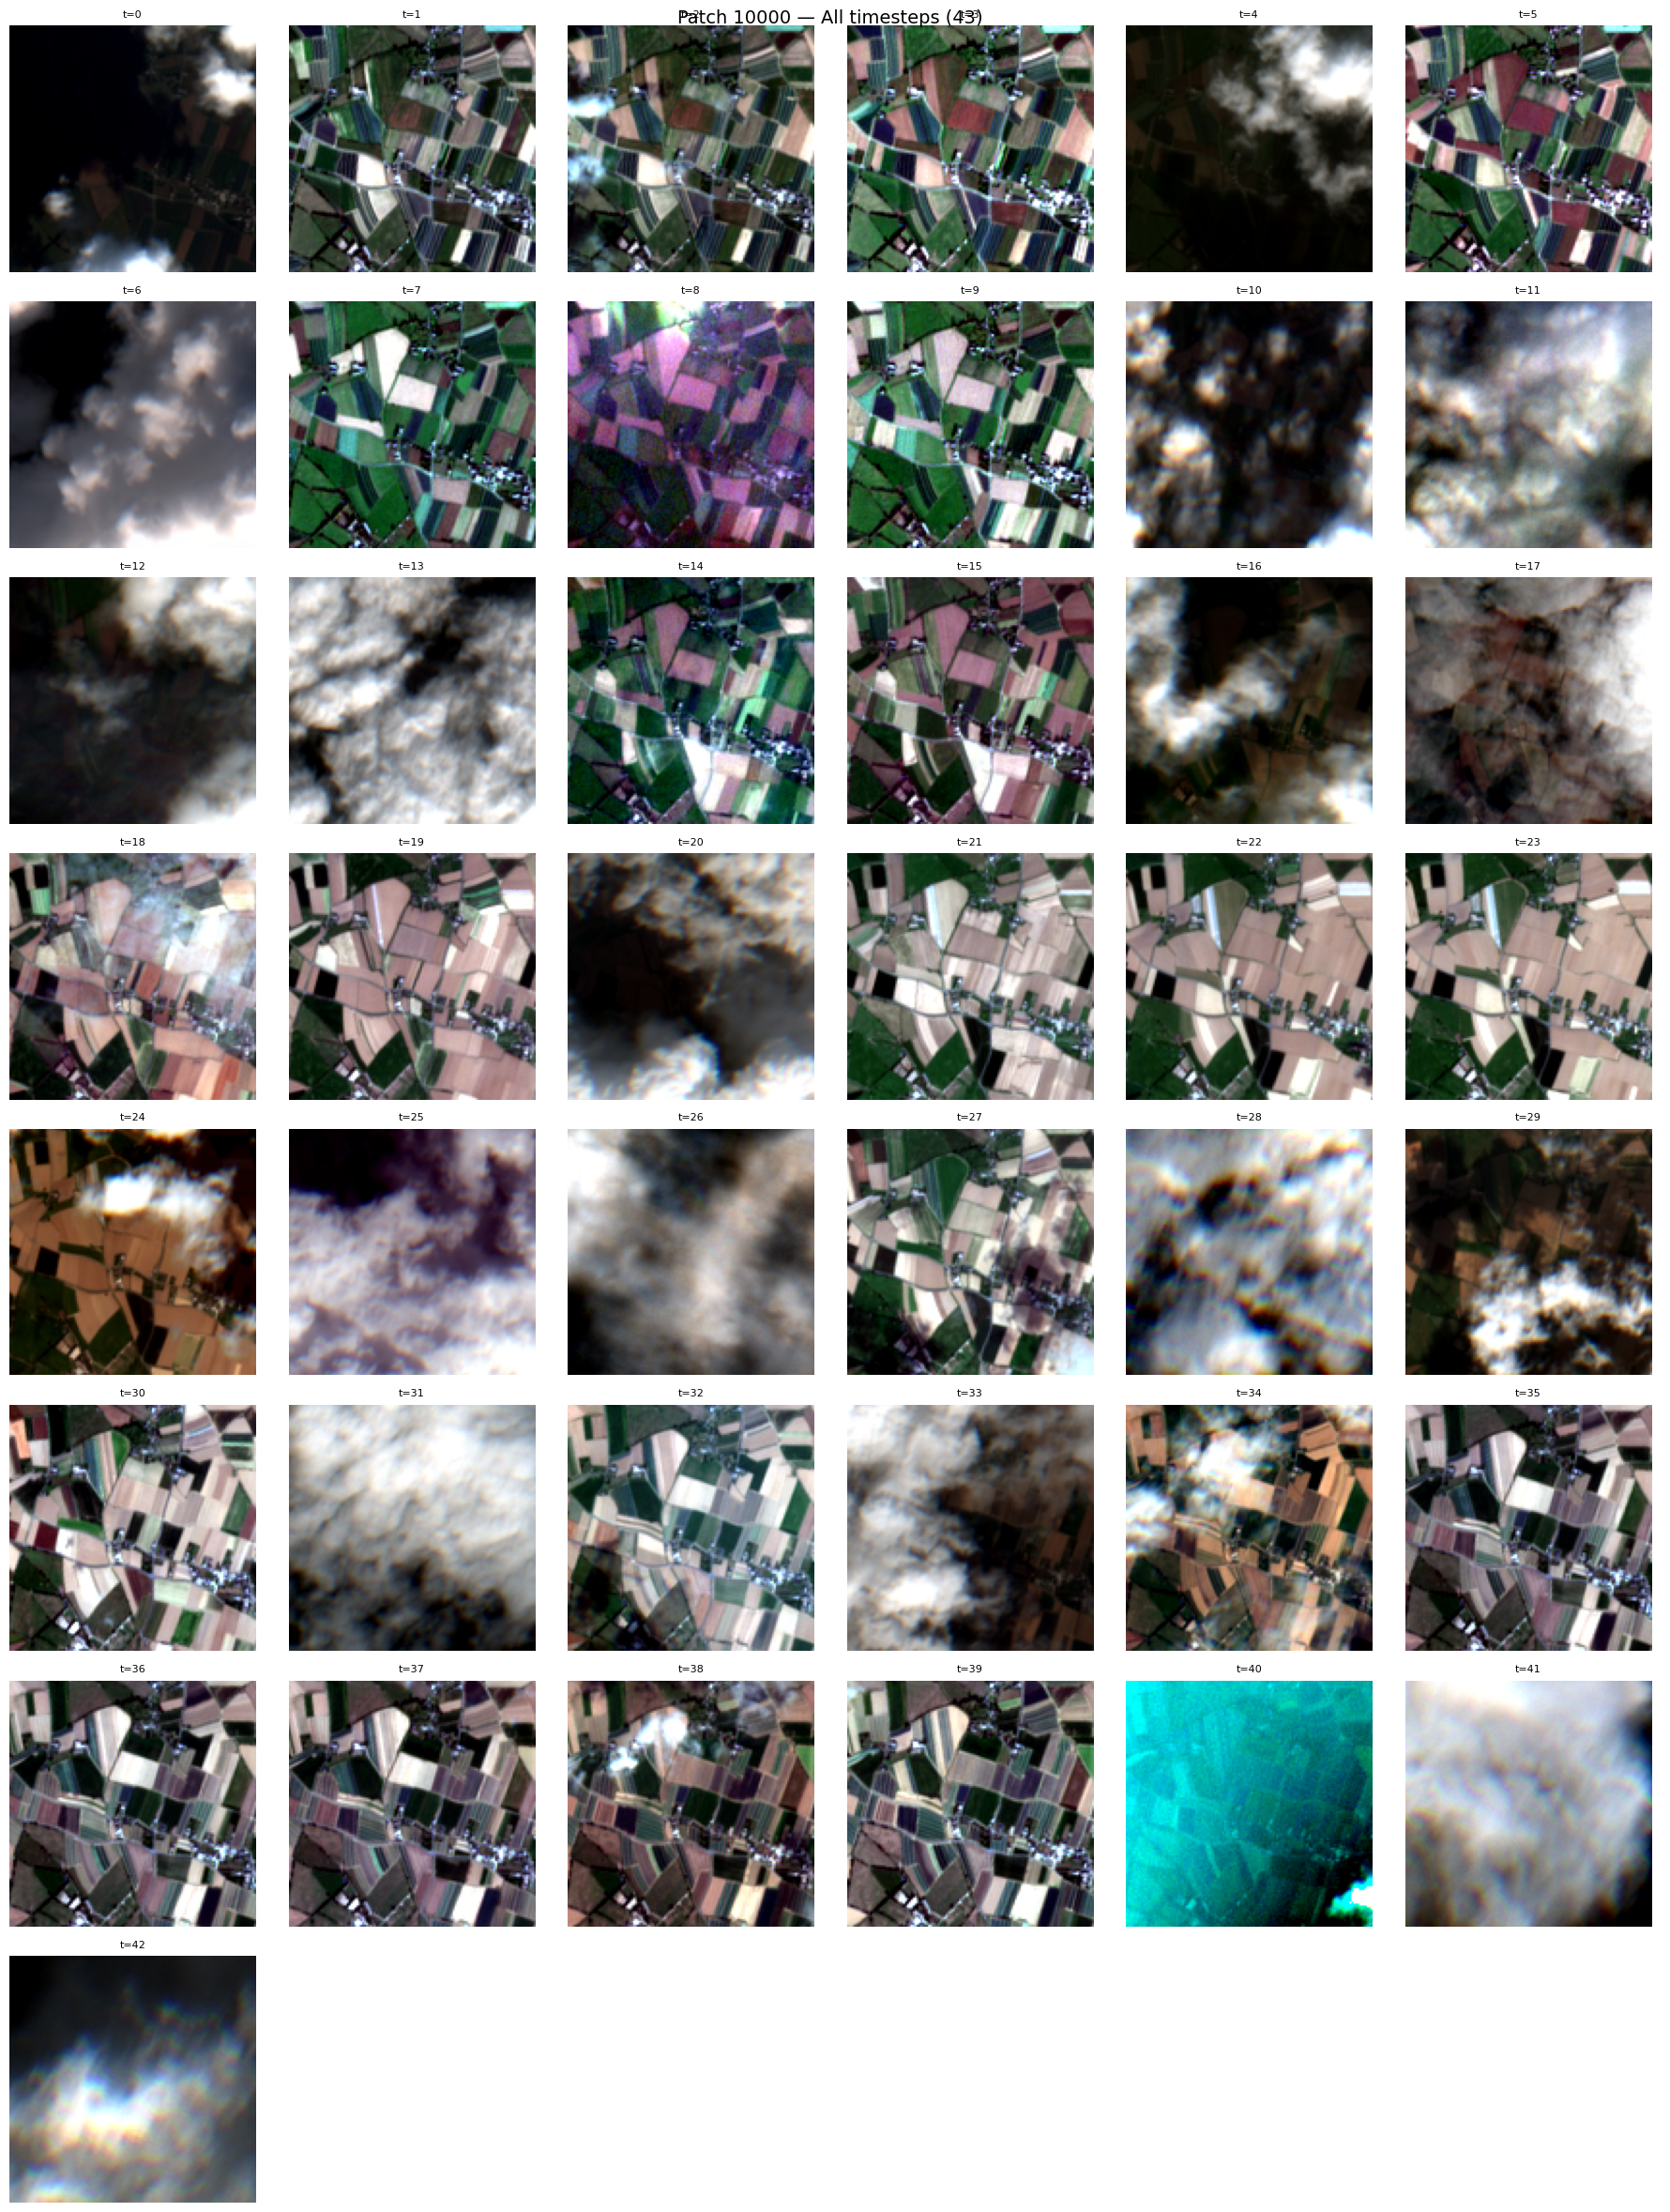

In [8]:
def show_timesteps(patch_id, n_cols=6):
    s2 = np.load(S2_DIR / f"S2_{patch_id}.npy").astype(np.float32)
    T = s2.shape[0]
    n_rows = int(np.ceil(T / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for t in range(T):
        rgb = s2[t, _RGB_IDX].transpose(1, 2, 0)
        for c in range(3):
            lo, hi = np.percentile(rgb[..., c], [2, 98])
            rgb[..., c] = np.clip((rgb[..., c] - lo) / max(hi - lo, 1), 0, 1)
        axes[t].imshow(rgb)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for t in range(T, len(axes)):
        axes[t].axis("off")
    fig.suptitle(f"Patch {patch_id} \u2014 All timesteps ({T})", fontsize=14)
    plt.tight_layout()
    plt.show()


show_timesteps(10000, n_cols=6)

## Parcel Border Overlay

In [7]:
def show_with_parcels(patch_id):
    rgb, labels = load_patch(patch_id)
    pid_map = np.load(ANN_DIR / f"ParcelIDs_{patch_id}.npy")
    rgb_display = rgb.copy()
    for c in range(3):
        lo, hi = np.percentile(rgb_display[..., c], [2, 98])
        rgb_display[..., c] = np.clip((rgb_display[..., c] - lo) / max(hi - lo, 1), 0, 1)
    edges_x = np.diff(pid_map, axis=1) != 0
    edges_y = np.diff(pid_map, axis=0) != 0
    edge_map = np.zeros_like(pid_map, dtype=bool)
    edge_map[:, :-1] |= edges_x
    edge_map[:-1, :] |= edges_y
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    axes[0].imshow(rgb_display)
    axes[0].set_title(f"Patch {patch_id} - RGB")
    axes[0].axis("off")
    overlay = rgb_display.copy()
    overlay[edge_map] = [1, 0, 0]
    axes[1].imshow(overlay)
    axes[1].set_title(f"Patch {patch_id} - RGB + Parcel borders")
    axes[1].axis("off")
    im = axes[2].imshow(labels, cmap="tab20", vmin=0, vmax=np.max(labels))
    axes[2].set_title(f"Patch {patch_id} - Labels")
    axes[2].axis("off")
    axes[2].figure.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


show_with_parcels(10000)

## Browse by Patch ID

Change `patch_id` below to explore different samples.

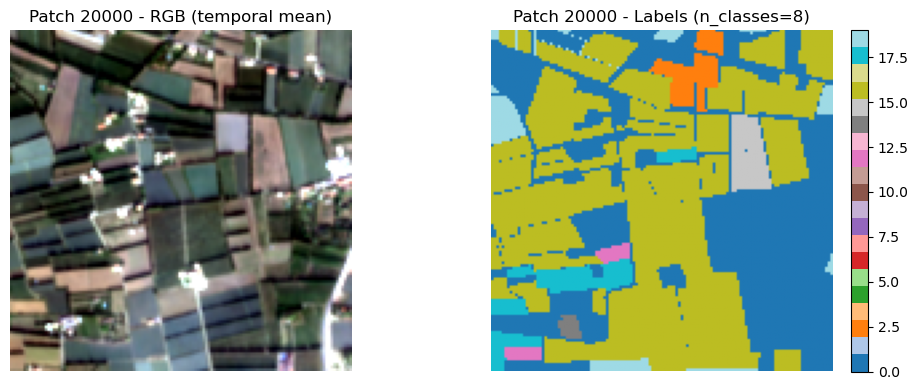

In [12]:
patch_id = 20000
show_patch(patch_id)